# 04 Decoding Ablation Experiments

## 1. Goal

We take the best three checkpoints from notebook 03 and try different decoding settings on each. The
sweep was saved, so by default we load and plot it per checkpoint; set RUN_DECODING=True to recompute.
The strongest combinations are then checked on the full test set to pick the final system.

## 2. Imports and run flags

These flags decide what runs. By default the notebook loads the saved decoding results instead of recomputing them.

In [1]:
import os, math
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import sacrebleu, sentencepiece as spm

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
torch.set_num_threads(8)
os.makedirs("outputs/figures", exist_ok=True)

RUN_DECODING = False      # recompute the sweep instead of loading it
FORCE_RESTART = False     # ignore saved results and rerun everything
print("RUN_DECODING", RUN_DECODING, "| FORCE_RESTART", FORCE_RESTART)

RUN_DECODING False | FORCE_RESTART False


## 3. Load tokenizers, test set and the top-3 checkpoints

We load the Arabic and English tokenizers and build the token to index tables.

In [2]:
sp_ar = spm.SentencePieceProcessor(model_file="Data/vocab/sp_ar.model")
sp_en = spm.SentencePieceProcessor(model_file="Data/vocab/sp_en.model")
ar_tokens = [l.split("\t")[0] for l in open("Data/vocab/sp_ar.vocab", encoding="utf-8").read().splitlines() if l]
en_tokens = [l.split("\t")[0] for l in open("Data/vocab/sp_en.vocab", encoding="utf-8").read().splitlines() if l]
ar_stoi = {t: i for i, t in enumerate(ar_tokens)}
en_itos = {i: t for i, t in enumerate(en_tokens)}
ar_pad, en_pad = ar_stoi["<pad>"], en_tokens.index("<pad>")
en_bos, en_eos = en_tokens.index("<s>"), en_tokens.index("</s>")

def read_bpe(p):
    return [l.split() for l in open(p, encoding="utf-8").read().splitlines()]

test = [(a, e) for a, e in zip(read_bpe("Data/tokenized/test.ar.bpe"), read_bpe("Data/tokenized/test.en.bpe"))
        if len(a) <= 80 and len(e) <= 80]
test_src = [" ".join(a) for a, e in test]
test_ref = [sp_en.decode(e) for a, e in test]
sub_src, sub_ref = test_src[:1000], test_ref[:1000]
sources = [sp_ar.decode(s.split()) for s in sub_src]

We load the best three checkpoints chosen in notebook 3.

In [3]:
top3 = pd.read_csv("outputs/tables/top3_training_checkpoints.csv")
top3[["category", "experiment", "bleu", "checkpoint"]]

,category,experiment,bleu,checkpoint
0,B. Regularization,Exp 2: weight decay 1e-4,18.7879,outputs/checkpoints/B_regularization/exp2_weig...
1,F. Combined,Combined: wd+ls+tie+warmup,12.1496,outputs/checkpoints/F_combined/exp1_combined/b...
2,D. Architecture,Exp 5: 3 layers,9.6330,outputs/checkpoints/D_architecture/exp5_depth3...


## 4. Decoding configurations

The decoding settings we will try on each checkpoint.

In [4]:
decoding_configs = pd.DataFrame([
    {"config": "greedy",          "beam": 1, "lp": 1.0, "nr": 0},
    {"config": "beam3 lp1.0 nr0", "beam": 3, "lp": 1.0, "nr": 0},
    {"config": "beam3 lp1.0 nr3", "beam": 3, "lp": 1.0, "nr": 3},
    {"config": "beam3 lp0.8 nr3", "beam": 3, "lp": 0.8, "nr": 3},
    {"config": "beam3 lp1.2 nr3", "beam": 3, "lp": 1.2, "nr": 3},
    {"config": "beam5 lp1.2 nr3", "beam": 5, "lp": 1.2, "nr": 3},
    {"config": "beam10 lp1.2 nr3", "beam": 10, "lp": 1.2, "nr": 3},
])
decoding_configs

,config,beam,lp,nr
0,greedy,1,1.0,0
1,beam3 lp1.0 nr0,3,1.0,0
2,beam3 lp1.0 nr3,3,1.0,3
3,beam3 lp0.8 nr3,3,0.8,3
4,beam3 lp1.2 nr3,3,1.2,3
5,beam5 lp1.2 nr3,5,1.2,3
6,beam10 lp1.2 nr3,10,1.2,3


## 5. Minimal model + decoding utilities

The positional encoding, which tells the model the position of each token.

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])

The tiny Transformer model used in every experiment.

In [6]:
class TinyTransformer(nn.Module):
    def __init__(self, d_model=128, num_layers=2):
        super().__init__()
        self.src_pad_id, self.tgt_pad_id, self.d_model = ar_pad, en_pad, d_model
        self.src_embedding = nn.Embedding(len(ar_tokens), d_model, padding_idx=ar_pad)
        self.tgt_embedding = nn.Embedding(len(en_tokens), d_model, padding_idx=en_pad)
        self.positional_encoding = PositionalEncoding(d_model, 0.1, 82)
        self.transformer = nn.Transformer(d_model, 4, num_layers, num_layers, 512, 0.1, batch_first=True)
        self.output_projection = nn.Linear(d_model, len(en_tokens))

    def forward(self, src, tgt_in):
        m = torch.triu(torch.ones(tgt_in.size(1), tgt_in.size(1), dtype=torch.bool), diagonal=1)
        sk, tk = src.eq(self.src_pad_id), tgt_in.eq(self.tgt_pad_id)
        se = self.positional_encoding(self.src_embedding(src) * math.sqrt(self.d_model))
        te = self.positional_encoding(self.tgt_embedding(tgt_in) * math.sqrt(self.d_model))
        h = self.transformer(se, te, tgt_mask=m, src_key_padding_mask=sk, tgt_key_padding_mask=tk, memory_key_padding_mask=sk)
        return self.output_projection(h)

Helpers that load a checkpoint at the right size, score the outputs, and measure repetition.

In [7]:
def load_checkpoint_for_decoding(path, experiment):
    d_model = 256 if "d_model 256" in experiment else (64 if "d_model 64" in experiment else 128)
    num_layers = 4 if "4+4 layers" in experiment else (3 if "3 layers" in experiment else (1 if "1 layer" in experiment else 2))
    model = TinyTransformer(d_model, num_layers)
    model.load_state_dict(torch.load(path, map_location="cpu", weights_only=False)["model_state_dict"]); model.eval()
    return model

def score_outputs(hyps, refs):
    return (round(sacrebleu.corpus_bleu(hyps, [refs]).score, 4),
            round(sacrebleu.corpus_chrf(hyps, [refs], word_order=2).score, 4))

def repetition_rate(hyps):
    n = sum(1 for h in hyps if len(h.split()) >= 4 and
            (len(list(zip(h.split(), h.split()[1:]))) - len(set(zip(h.split(), h.split()[1:]))) >= 2
             or len(set(h.split())) / len(h.split()) < 0.5))
    return round(100 * n / max(1, len(hyps)), 1)

Beam search decoding for a single sentence.

In [8]:
@torch.no_grad()
def decode_sentence(model, src_line, beam=3, lp=1.0, nr=3):
    model.eval()
    src = torch.tensor([[ar_stoi["<s>"]] + [ar_stoi.get(p, ar_stoi["<unk>"]) for p in src_line.split()] + [ar_stoi["</s>"]]])
    pad = src.eq(model.src_pad_id)
    mem = model.transformer.encoder(model.positional_encoding(model.src_embedding(src) * math.sqrt(model.d_model)),
                                    src_key_padding_mask=pad).expand(beam, -1, -1).contiguous()
    mpad = pad.expand(beam, -1).contiguous()
    ys = torch.full((beam, 1), en_bos, dtype=torch.long)
    scores = torch.full((beam,), float("-inf")); scores[0] = 0.0; done = []
    for _ in range(80):
        L = ys.size(1); cm = torch.triu(torch.ones(L, L, dtype=torch.bool), diagonal=1)
        dec = model.transformer.decoder(model.positional_encoding(model.tgt_embedding(ys) * math.sqrt(model.d_model)),
                                        mem, tgt_mask=cm, memory_key_padding_mask=mpad)
        logp = torch.log_softmax(model.output_projection(dec[:, -1]), dim=-1)
        for b in range(beam):
            seq = ys[b].tolist()
            if nr and len(seq) >= nr:
                prev = tuple(seq[-(nr - 1):]) if nr > 1 else ()
                ban = [tuple(seq[i:i + nr])[-1] for i in range(len(seq) - nr + 1) if tuple(seq[i:i + nr])[:-1] == prev]
                if ban: logp[b, ban] = float("-inf")
        V = logp.size(-1); s, idx = (scores.unsqueeze(1) + logp).view(-1).topk(beam)
        ys = torch.cat([ys[torch.div(idx, V, rounding_mode="floor")], (idx % V).unsqueeze(1)], 1); scores = s.clone()
        for b in range(beam):
            if (idx[b] % V).item() == en_eos:
                done.append((scores[b].item() / max(1, ys.size(1) - 1) ** lp, ys[b].tolist())); scores[b] = float("-inf")
        if len(done) >= beam or torch.isinf(scores).all():
            break
    if not done:
        done.append((0.0, ys[int(scores.argmax())].tolist()))
    out = max(done, key=lambda x: x[0])[1]
    return sp_en.decode([en_itos.get(int(i), "<unk>") for i in out if int(i) not in (en_pad, en_bos, en_eos)])

We load the saved decoding sweep, recompute it only if the flag is on, and add a small plotting helper.

In [9]:
# saved sweep (loaded by default; recomputed only if RUN_DECODING)
saved_sweep = pd.read_csv("outputs/tables/decoding_sweep_1000.csv") if os.path.exists("outputs/tables/decoding_sweep_1000.csv") else None

def load_or_run_decoding(experiment, model):
    if not RUN_DECODING and saved_sweep is not None and experiment in set(saved_sweep["experiment"]):
        return saved_sweep[saved_sweep["experiment"] == experiment].copy()
    rows = []
    for _, c in decoding_configs.iterrows():
        hyps = [decode_sentence(model, s, int(c["beam"]), float(c["lp"]), int(c["nr"])) for s in sub_src]
        bleu, chrf = score_outputs(hyps, sub_ref)
        rows.append({"experiment": experiment, "config": c["config"], "bleu": bleu, "chrf_pp": chrf, "rep_pct": repetition_rate(hyps)})
    return pd.DataFrame(rows)

def plot_decoding(table, name, prefix):
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
    for ax, m, c in zip(axes, ["bleu", "chrf_pp", "rep_pct"], ["tab:blue", "tab:green", "tab:orange"]):
        d = table.sort_values(m, ascending=(m == "rep_pct"))
        ax.bar(d["config"], d[m], color=c); ax.set_title(m); ax.tick_params(axis="x", rotation=35)
    fig.suptitle(name); fig.tight_layout(); fig.savefig(f"outputs/figures/{prefix}.png"); plt.show()

sweeps = []

## Checkpoint 1

The strongest training checkpoint. We test every decoding setting on it.

We pick this checkpoint and run, or load, every decoding setting on it.

In [10]:
row = top3.iloc[0]
print("model:", row["experiment"], "| category:", row["category"], "| training BLEU:", row["bleu"])
print("checkpoint:", row["checkpoint"])
model = load_checkpoint_for_decoding(row["checkpoint"], row["experiment"])
table = load_or_run_decoding(row["experiment"], model).sort_values("bleu", ascending=False).reset_index(drop=True)
sweeps.append(table)
table

model: Exp 2: weight decay 1e-4 | category: B. Regularization | training BLEU: 18.7879
checkpoint: outputs/checkpoints/B_regularization/exp2_weight_decay/best.pt


,experiment,config,bleu,chrf_pp,rep_pct
0,Exp 2: weight decay 1e-4,beam10 lp1.2 nr3,19.3666,41.7021,4.1
1,Exp 2: weight decay 1e-4,beam5 lp1.2 nr3,19.2228,41.5140,4.5
2,Exp 2: weight decay 1e-4,beam3 lp0.8 nr3,18.9190,40.9118,4.8
3,Exp 2: weight decay 1e-4,beam3 lp1.0 nr0,18.8708,41.0998,14.3
4,Exp 2: weight decay 1e-4,beam3 lp1.0 nr3,18.7879,41.0371,4.8
5,Exp 2: weight decay 1e-4,beam3 lp1.2 nr3,18.6425,41.1195,4.8
6,Exp 2: weight decay 1e-4,greedy,17.7212,39.8874,15.5


BLEU, chrF++ and repetition for each decoding setting on this checkpoint.

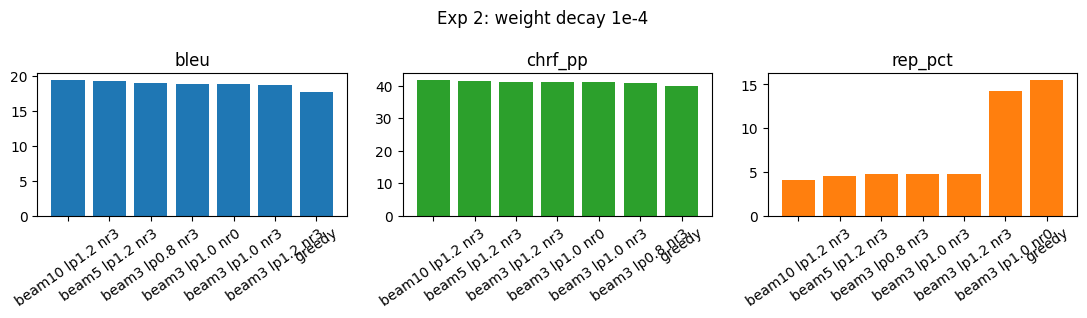

In [11]:
plot_decoding(table, row["experiment"], "decoding_checkpoint1")

The best setting for this checkpoint, with a few example translations.

In [12]:
best = table.iloc[0]
cfg = decoding_configs[decoding_configs["config"] == best["config"]].iloc[0]
print("best decoding for this checkpoint:", best["config"], "| BLEU", best["bleu"])
pd.DataFrame({"source": sources[:4], "reference": sub_ref[:4],
              "prediction": [decode_sentence(model, s, int(cfg["beam"]), float(cfg["lp"]), int(cfg["nr"])) for s in sub_src[:4]]})

best decoding for this checkpoint: beam10 lp1.2 nr3 | BLEU 19.3666


D:\Ahmed Sherif\Digilians\Deep Learning\Project\Low-Resource Machine Translation with Tiny Transformers\.venv\Lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


,source,reference,prediction
0,قبل عدة سنوات، هنا في تيد، قدّم بيتر سكيلمان م...,"several years ago here at ted, peter skillman ...","a couple of years ago, here at ted, i've devel..."
1,والفكرة غاية في البساطة. فريق مكوّن من اربعة ي...,and the idea's pretty simple: teams of four ha...,and the idea is very simple in simplicity. a t...
2,يجب ان تكون المارش مالو علي القمة.,the marshmallow has to be on top.,it should be familiar with the top.
3,ورغماً عن انها تبدو بسيطة للغاية، الا انها صعب...,"and, though it seems really simple, it's actua...","and even though it looks very simple, it's ver..."


Repetition control (`nr3`) and a small length penalty give the best result here.

## Checkpoint 2

The second checkpoint, tested with the same decoding settings.

We pick this checkpoint and run, or load, every decoding setting on it.

In [13]:
row = top3.iloc[1]
print("model:", row["experiment"], "| category:", row["category"], "| training BLEU:", row["bleu"])
print("checkpoint:", row["checkpoint"])
model = load_checkpoint_for_decoding(row["checkpoint"], row["experiment"])
table = load_or_run_decoding(row["experiment"], model).sort_values("bleu", ascending=False).reset_index(drop=True)
sweeps.append(table)
table

model: Combined: wd+ls+tie+warmup | category: F. Combined | training BLEU: 12.1496
checkpoint: outputs/checkpoints/F_combined/exp1_combined/best.pt


,experiment,config,bleu,chrf_pp,rep_pct
0,Combined: wd+ls+tie+warmup,beam3 lp0.8 nr3,12.3328,32.7430,14.2
1,Combined: wd+ls+tie+warmup,beam3 lp1.0 nr3,12.1496,33.0749,14.5
2,Combined: wd+ls+tie+warmup,beam10 lp1.2 nr3,12.1003,33.3994,14.5
3,Combined: wd+ls+tie+warmup,beam5 lp1.2 nr3,12.0632,33.2752,15.3
4,Combined: wd+ls+tie+warmup,beam3 lp1.2 nr3,11.9505,33.3162,15.8
5,Combined: wd+ls+tie+warmup,beam3 lp1.0 nr0,11.6387,32.2909,34.1
6,Combined: wd+ls+tie+warmup,greedy,10.7230,31.3324,36.1


BLEU, chrF++ and repetition for each decoding setting on this checkpoint.

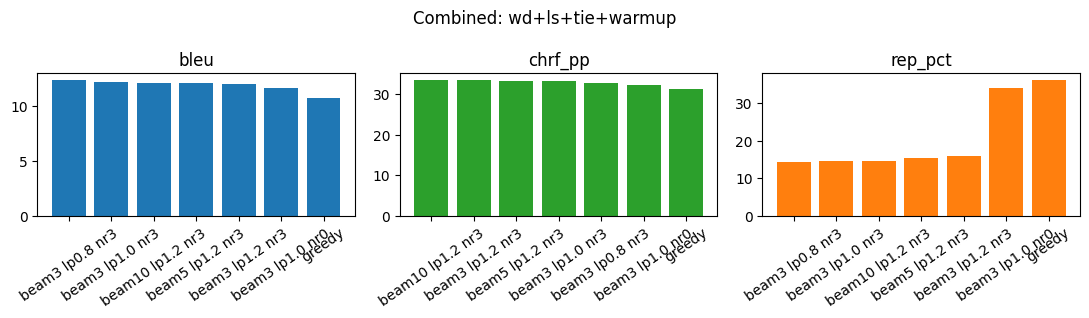

In [14]:
plot_decoding(table, row["experiment"], "decoding_checkpoint2")

The best setting for this checkpoint, with a few example translations.

In [15]:
best = table.iloc[0]
cfg = decoding_configs[decoding_configs["config"] == best["config"]].iloc[0]
print("best decoding for this checkpoint:", best["config"], "| BLEU", best["bleu"])
pd.DataFrame({"source": sources[:4], "reference": sub_ref[:4],
              "prediction": [decode_sentence(model, s, int(cfg["beam"]), float(cfg["lp"]), int(cfg["nr"])) for s in sub_src[:4]]})

best decoding for this checkpoint: beam3 lp0.8 nr3 | BLEU 12.3328


,source,reference,prediction
0,قبل عدة سنوات، هنا في تيد، قدّم بيتر سكيلمان م...,"several years ago here at ted, peter skillman ...","a few years ago, in ted, we've been able to cr..."
1,والفكرة غاية في البساطة. فريق مكوّن من اربعة ي...,and the idea's pretty simple: teams of four ha...,and the idea is very simple. it's a team of a ...
2,يجب ان تكون المارش مالو علي القمة.,the marshmallow has to be on top.,it should be money on the top.
3,ورغماً عن انها تبدو بسيطة للغاية، الا انها صعب...,"and, though it seems really simple, it's actua...","and even though it looks very simple, it's ver..."


Same pattern, but lower overall than checkpoint 1.

## Checkpoint 3

The third checkpoint, for completeness.

We pick this checkpoint and run, or load, every decoding setting on it.

In [16]:
row = top3.iloc[2]
print("model:", row["experiment"], "| category:", row["category"], "| training BLEU:", row["bleu"])
print("checkpoint:", row["checkpoint"])
model = load_checkpoint_for_decoding(row["checkpoint"], row["experiment"])
table = load_or_run_decoding(row["experiment"], model).sort_values("bleu", ascending=False).reset_index(drop=True)
sweeps.append(table)
table

model: Exp 5: 3 layers | category: D. Architecture | training BLEU: 9.633
checkpoint: outputs/checkpoints/D_architecture/exp5_depth3/best.pt


,experiment,config,bleu,chrf_pp,rep_pct
0,Exp 5: 3 layers,beam10 lp1.2 nr3,9.9546,31.1307,11.3
1,Exp 5: 3 layers,beam5 lp1.2 nr3,9.7861,30.9236,13.5
2,Exp 5: 3 layers,beam3 lp1.0 nr3,9.6330,30.4201,13.8
3,Exp 5: 3 layers,beam3 lp1.2 nr3,9.5665,30.7992,14.7
4,Exp 5: 3 layers,beam3 lp0.8 nr3,9.5352,30.1962,13.3
5,Exp 5: 3 layers,beam3 lp1.0 nr0,9.1653,28.8222,44.1
6,Exp 5: 3 layers,greedy,7.5199,28.1226,48.1


BLEU, chrF++ and repetition for each decoding setting on this checkpoint.

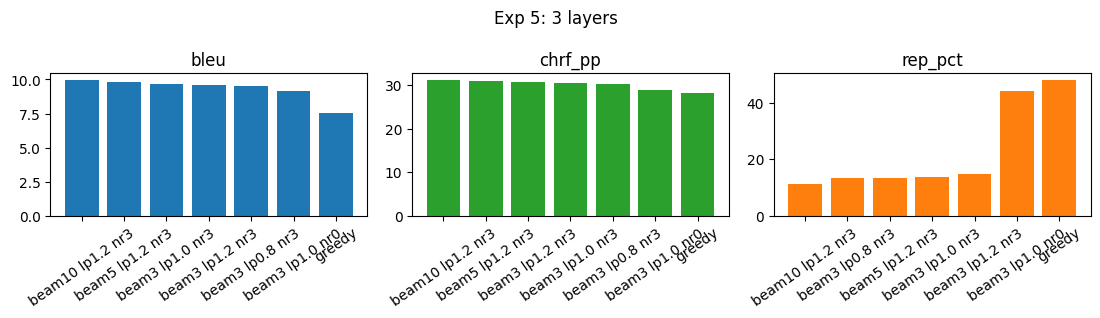

In [17]:
plot_decoding(table, row["experiment"], "decoding_checkpoint3")

The best setting for this checkpoint, with a few example translations.

In [18]:
best = table.iloc[0]
cfg = decoding_configs[decoding_configs["config"] == best["config"]].iloc[0]
print("best decoding for this checkpoint:", best["config"], "| BLEU", best["bleu"])
pd.DataFrame({"source": sources[:4], "reference": sub_ref[:4],
              "prediction": [decode_sentence(model, s, int(cfg["beam"]), float(cfg["lp"]), int(cfg["nr"])) for s in sub_src[:4]]})

best decoding for this checkpoint: beam10 lp1.2 nr3 | BLEU 9.9546


,source,reference,prediction
0,قبل عدة سنوات، هنا في تيد، قدّم بيتر سكيلمان م...,"several years ago here at ted, peter skillman ...","here's a few years ago, i've been borrowed for..."
1,والفكرة غاية في البساطة. فريق مكوّن من اربعة ي...,and the idea's pretty simple: teams of four ha...,it's a very elegant piece of a piece of packag...
2,يجب ان تكون المارش مالو علي القمة.,the marshmallow has to be on top.,you have to be familiar with money.
3,ورغماً عن انها تبدو بسيطة للغاية، الا انها صعب...,"and, though it seems really simple, it's actua...","it's very simple, very simple because they see..."


Again `nr3` helps; overall lower than the top checkpoint.

## Combined subset ranking
All model + decoding combinations, ranked by BLEU.

All checkpoint and decoding combinations, ranked together.

In [19]:
combined = pd.concat(sweeps).sort_values("bleu", ascending=False).reset_index(drop=True)
combined["label"] = combined["experiment"].str.replace("Exp ", "") + " | " + combined["config"]
combined.head(12)[["experiment", "config", "bleu", "chrf_pp", "rep_pct"]]

,experiment,config,bleu,chrf_pp,rep_pct
0,Exp 2: weight decay 1e-4,beam10 lp1.2 nr3,19.3666,41.7021,4.1
1,Exp 2: weight decay 1e-4,beam5 lp1.2 nr3,19.2228,41.5140,4.5
2,Exp 2: weight decay 1e-4,beam3 lp0.8 nr3,18.9190,40.9118,4.8
3,Exp 2: weight decay 1e-4,beam3 lp1.0 nr0,18.8708,41.0998,14.3
4,Exp 2: weight decay 1e-4,beam3 lp1.0 nr3,18.7879,41.0371,4.8
5,Exp 2: weight decay 1e-4,beam3 lp1.2 nr3,18.6425,41.1195,4.8
6,Exp 2: weight decay 1e-4,greedy,17.7212,39.8874,15.5
7,Combined: wd+ls+tie+warmup,beam3 lp0.8 nr3,12.3328,32.7430,14.2
8,Combined: wd+ls+tie+warmup,beam3 lp1.0 nr3,12.1496,33.0749,14.5
9,Combined: wd+ls+tie+warmup,beam10 lp1.2 nr3,12.1003,33.3994,14.5


The ten best combinations, as bar charts.

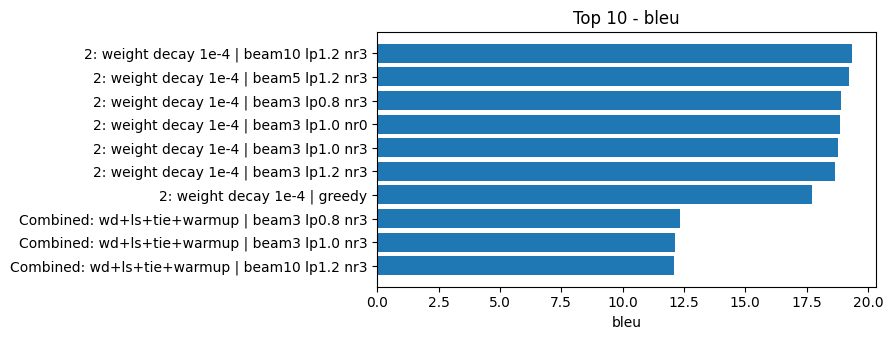

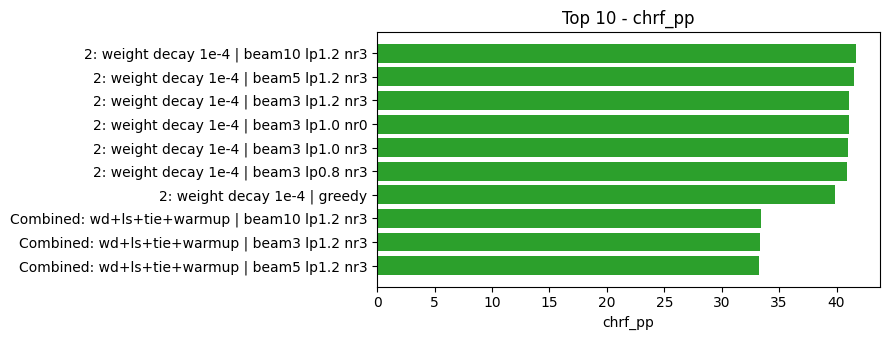

In [20]:
for m, c, fn in [("bleu", "tab:blue", "decoding_overall_top10_bleu.png"),
                  ("chrf_pp", "tab:green", "decoding_overall_top10_chrf.png")]:
    d = combined.sort_values(m, ascending=False).head(10)
    plt.figure(figsize=(9, 3.5)); plt.barh(d["label"][::-1], d[m][::-1], color=c)
    plt.xlabel(m); plt.title("Top 10 - " + m); plt.tight_layout()
    plt.savefig("outputs/figures/" + fn); plt.show()

## Full-test candidates and result
The best setting of each checkpoint is evaluated on the full test set.

The best setting of each checkpoint, scored on the full test set.

In [21]:
full_test = pd.read_csv("outputs/tables/final_decoding_candidates_full_test.csv")
full_test

,experiment,config,bleu,chrf_pp,rep_pct,n
0,Exp 2: weight decay 1e-4,beam10 lp1.2 nr3,19.9069,42.2428,4.6,8491
1,Combined: wd+ls+tie+warmup,beam3 lp0.8 nr3,12.3177,32.9156,16.6,8491
2,Exp 5: 3 layers,beam10 lp1.2 nr3,9.7697,30.8195,15.0,8491


Full test BLEU for the candidate systems.

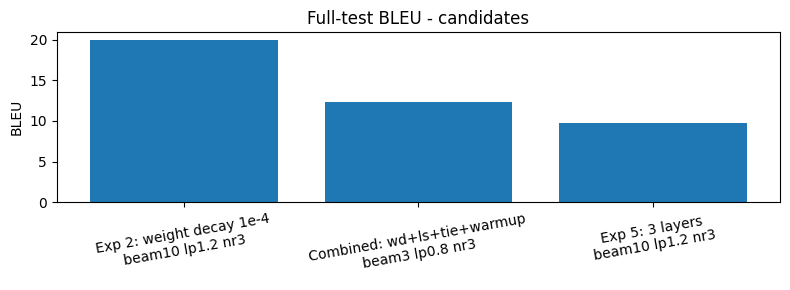

In [22]:
plt.figure(figsize=(8, 3))
plt.bar(full_test["experiment"] + "\n" + full_test["config"], full_test["bleu"], color="tab:blue")
plt.ylabel("BLEU"); plt.title("Full-test BLEU - candidates"); plt.xticks(rotation=10); plt.tight_layout()
plt.savefig("outputs/figures/decoding_final_full_test_bleu.png"); plt.show()

## Final decoding choice

We load every saved result table that this notebook presents.

In [23]:
final = pd.read_csv("outputs/tables/final_model_decoding_result.csv").iloc[0]
print("Final checkpoint :", final["final_model"])
print("Final decoding   :", final["decoding"])
print("Full-test BLEU   :", final["bleu"])
print("Full-test chrF++ :", final["chrf_pp"])
print("Repetition rate  :", final["rep_pct"], "%")
final

Final checkpoint : Exp 2: weight decay 1e-4
Final decoding   : beam10 lp1.2 nr3
Full-test BLEU   : 19.9069
Full-test chrF++ : 42.2428
Repetition rate  : 4.6 %


final_model      Exp 2: weight decay 1e-4
decoding                 beam10 lp1.2 nr3
test_examples                        8491
bleu                              19.9069
chrf_pp                           42.2428
rep_pct                               4.6
Name: 0, dtype: object

The **final checkpoint and decoding configuration** are printed by the code cell above, loaded directly from outputs/tables/final_model_decoding_result.csv. The winner is determined by full-test BLEU across the top-3 training checkpoints with all decoding settings swept. This result feeds notebook 05.